In [20]:
# integrate and fire model parameters

import numpy as np
import matplotlib.pyplot as plt

N_Ex, N_Inh = 320, 80
N = N_Ex + N_Inh
W = np.zeros((N, N))

# Initializing the connectivity matrix by a uniform random selection
for i in range(N):
    if i < N_Ex:
        Ex_conncetions = np.random.choice(a = np.delete(np.arange(N_Ex), i), size = 20, replace=False)
        In_conncetions = np.random.choice(a = np.arange(N_Ex, N), size = 5, replace=False)
        W[i, Ex_conncetions] = 1
        W[i, In_conncetions] = -1
    elif i >= N_Ex:
        Ex_conncetions = np.random.choice(a = np.arange(N_Ex), size = 5, replace=False)
        W[i, Ex_conncetions] = 1
    
V_rest = -60 # mV
V_threshold_Ex, V_threshold_Inh = np.random.normal(-40, 0.05*40, N_Ex), np.random.normal(-45, 0.05*45, N_Inh) # mV
V_reset_Ex, V_reset_Inh = -60, -65 # mV

tau_Ex, tau_Inh = 30, 10 # mS


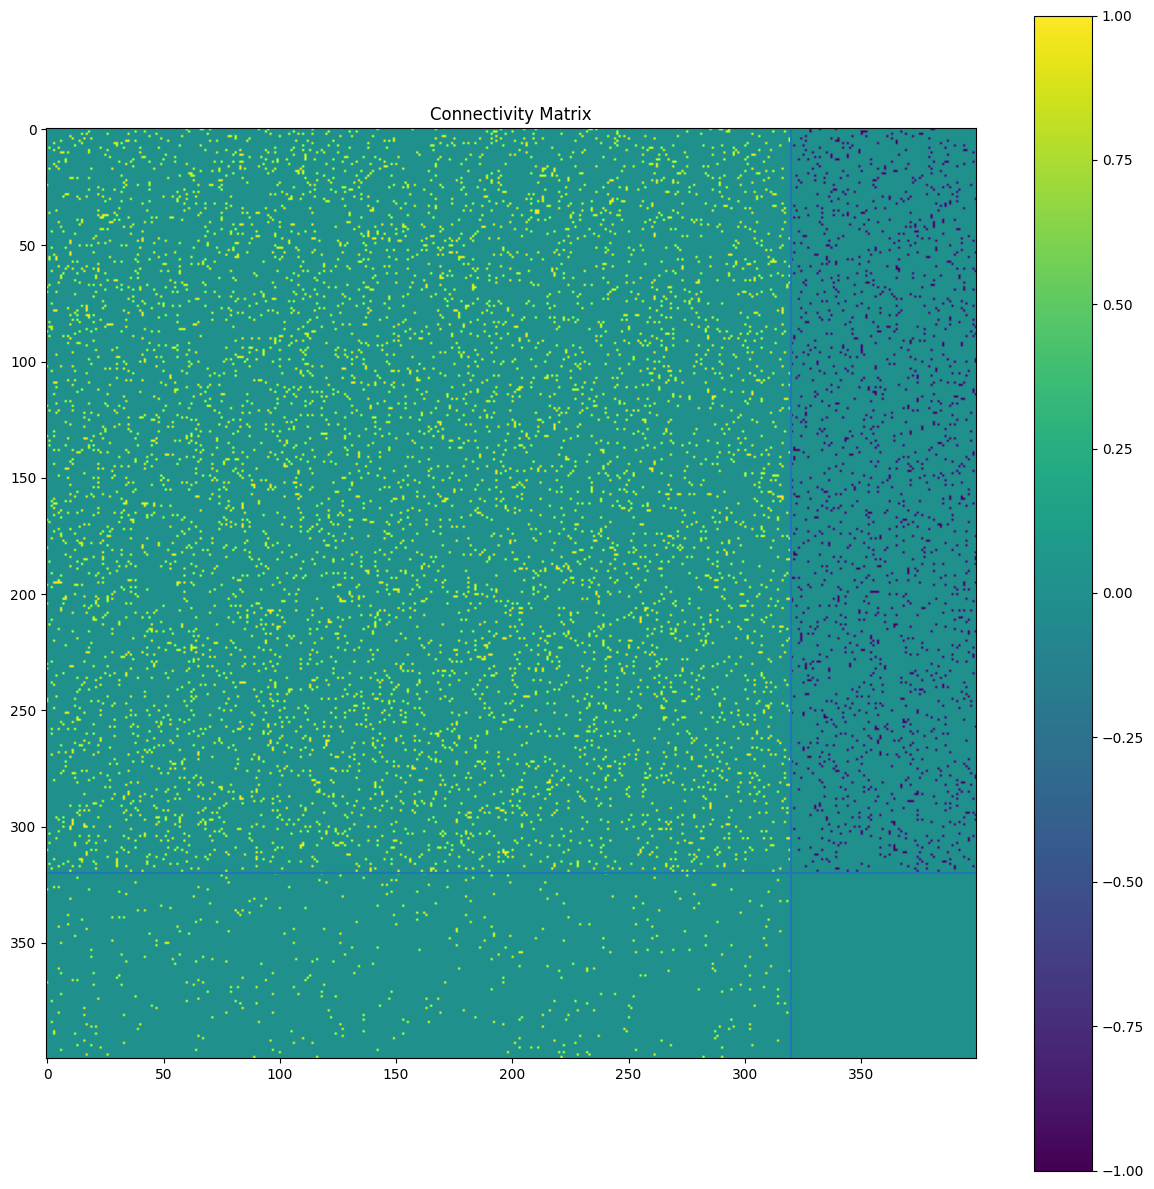

In [28]:
# Visualization of initial connectivity matrix 
plt.figure(figsize=(15, 15))
ax = plt.subplot()
plt.title("Connectivity Matrix")


plt.imshow(W)
plt.colorbar()
plt.axvline(x=320, ymin=0, ymax=1)
plt.axhline(y=320, xmin=0, xmax=1)
plt.show()

In [ ]:
dt = 0.1
T = 400
n_t = int(T/dt)

R = 300*1e6 # Input resistance (Ohm)
alpha = 0.05 # learning rate
v = V_rest + np.zeros((N, 1))


for i in range(n_t):
    v[:N_Ex, 1] = v[:N_Ex, 1] + (-(v[:N_Ex, 1] - V_rest) + R*I[:N_Ex])*dt/tau_Ex
    v[N_Ex:N, 1] = v[N_Ex:N, 1] + (-(v[N_Ex:N, 1] - V_rest) + R*I[N_Ex:N])*dt/tau_Inh
    
    v[np.where(v[:N_Ex] > V_threshold_Ex)] = V_reset_Ex
    v[np.where(v[N_Ex:N] > V_threshold_Inh)] = V_reset_Inh
    
    

(400,)